# CSCI E-89 Deep Learning, Assignment 01
### Zoe Buck

Problem 6 reproduces the lecture notebook `Lec01_Introduction_Simple_Example.ipynb` and extends it with the sample-prediction and reduced-training-set experiments required by the assignment.

### Environment check

A quick check that TensorFlow imports, that the GPU is visible, and that tensors can be created.

In [1]:
import tensorflow as tf

I0000 00:00:1789218562.611697    9369 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
tf.constant([1, 2, 3])

I0000 00:00:1789218565.186104    9369 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15628 MB memory:  -> device: 0, name: AMD Radeon RX 6800 XT, pci bus id: 0000:03:00.0


<tf.Tensor: shape=(3,), dtype=int32, numpy=array([1, 2, 3], dtype=int32)>

## Problem 1:
I created a Python virtual environment for this assignment using Python's built-in venv module instead of Conda. The environment was created with the command `python -m venv csci-e89` and activated using `source csci-e89/bin/activate`.

The virtual environment uses Python 3.10.21, and I also verified that pip is installed and available within the environment. The installed version is pip 23.0.1.

I used `pip list` to examine the packages installed in the virtual environment. The output is included below. I also examined the Python environments available on my system and verified that my system Python version is Python 3.10.21. Terminal output:

```bash
zoe@zoe-MS-7C75:~/Github/deep_learning_course$ source csci-e89/bin/activate
(csci-e89) zoe@zoe-MS-7C75:~/Github/deep_learning_course$ python --version
Python 3.10.21
(csci-e89) zoe@zoe-MS-7C75:~/Github/deep_learning_course$ pip --version
pip 23.0.1 from /home/zoe/Github/deep_learning_course/csci-e89/lib/python3.10/site-packages/pip (python 3.10)
(csci-e89) zoe@zoe-MS-7C75:~/Github/deep_learning_course$ pip list
Package                      Version
---------------------------- ---------------
absl-py                      2.5.0
anyio                        4.15.1
argon2-cffi                  25.1.0
argon2-cffi-bindings         26.1.0
arrow                        1.4.0
asttokens                    3.0.2
astunparse                   1.6.3
async-lru                    2.3.0
attrs                        26.1.0
babel                        2.18.0
beautifulsoup4               4.15.0
bleach                       6.4.0
certifi                      2026.7.22
cffi                         2.1.1
charset-normalizer           3.5.1
comm                         0.2.3
contourpy                    1.3.2
cycler                       0.12.1
debugpy                      1.8.21
decorator                    5.3.1
defusedxml                   0.7.1
exceptiongroup               1.3.1
executing                    2.2.1
fastjsonschema               2.22.2
filelock                     3.32.3
flatbuffers                  25.12.19
fonttools                    4.64.0
fqdn                         1.5.1
fsspec                       2026.7.0
gast                         0.7.0
google-pasta                 0.2.0
grpcio                       1.83.1
h11                          0.16.0
h5py                         3.14.0
httpcore                     1.0.9
httpx                        0.28.1
idna                         3.19
ipykernel                    7.3.0
ipython                      8.39.0
isoduration                  20.11.0
jedi                         0.20.0
Jinja2                       3.1.6
json5                        0.15.0
jsonpointer                  3.1.1
jsonschema                   4.26.0
jsonschema-specifications    2025.9.1
jupter                       0.1.0
jupyter_builder              1.2.3
jupyter_client               8.10.0
jupyter_core                 5.9.1
jupyter-events               0.12.1
jupyter-lsp                  2.3.1
jupyter_server               2.21.0
jupyter_server_terminals     0.5.4
jupyterlab                   4.6.3
jupyterlab_pygments          0.3.0
jupyterlab_server            2.28.0
keras                        3.12.4
kiwisolver                   1.5.1
lark                         1.3.1
libclang                     18.1.1
Markdown                     3.10.3
markdown-it-py               4.2.0
MarkupSafe                   3.0.3
matplotlib                   3.10.9
matplotlib-inline            0.2.2
mdurl                        0.1.2
mistune                      3.3.4
ml_dtypes                    0.6.0
mpmath                       1.3.0
namex                        0.1.0
nbclient                     0.11.0
nbconvert                    7.17.1
nbformat                     5.11.1
nest-asyncio2                1.7.2
networkx                     3.4.2
notebook                     7.6.2
notebook_shim                0.2.4
numpy                        2.1.3
nvidia-cublas-cu12           12.1.3.1
nvidia-cuda-cupti-cu12       12.1.105
nvidia-cuda-nvrtc-cu12       12.1.105
nvidia-cuda-runtime-cu12     12.1.105
nvidia-cudnn-cu12            9.1.0.70
nvidia-cufft-cu12            11.0.2.54
nvidia-curand-cu12           10.3.2.106
nvidia-cusolver-cu12         11.4.5.107
nvidia-cusparse-cu12         12.1.0.106
nvidia-nccl-cu12             2.21.5
nvidia-nvjitlink-cu12        12.9.86
nvidia-nvtx-cu12             12.1.105
opt_einsum                   3.4.0
optree                       0.20.0
overrides                    7.7.0
packaging                    26.3
pandas                       2.3.3
pandocfilters                1.5.1
parso                        0.8.7
pexpect                      4.9.0
pillow                       12.3.0
pip                          23.0.1
platformdirs                 4.11.7
prometheus_client            0.26.0
prompt_toolkit               3.0.53
protobuf                     5.29.6
psutil                       7.2.2
ptyprocess                   0.7.0
pure_eval                    0.2.3
pycparser                    3.0
Pygments                     2.21.0
pyparsing                    3.3.2
python-dateutil              2.9.0.post0
python-json-logger           4.2.0
pytz                         2026.3.post1
PyYAML                       6.0.3
pyzmq                        27.2.0
referencing                  0.37.0
requests                     2.34.2
rfc3339-validator            0.1.4
rfc3986-validator            0.1.1
rfc3987-syntax               1.1.0
rich                         15.0.0
rocm                         7.14.1
rocm-sdk-core                7.14.1
rocm-sdk-device-gfx1010      7.14.1
rocm-sdk-device-gfx1011      7.14.1
rocm-sdk-device-gfx1012      7.14.1
rocm-sdk-device-gfx1030      7.14.1
rocm-sdk-device-gfx1031      7.14.1
rocm-sdk-device-gfx1032      7.14.1
rocm-sdk-device-gfx1033      7.14.1
rocm-sdk-device-gfx1034      7.14.1
rocm-sdk-device-gfx1035      7.14.1
rocm-sdk-device-gfx1036      7.14.1
rocm-sdk-device-gfx1100      7.14.1
rocm-sdk-device-gfx1101      7.14.1
rocm-sdk-device-gfx1102      7.14.1
rocm-sdk-device-gfx1103      7.14.1
rocm-sdk-device-gfx1150      7.14.1
rocm-sdk-device-gfx1151      7.14.1
rocm-sdk-device-gfx1152      7.14.1
rocm-sdk-device-gfx1153      7.14.1
rocm-sdk-device-gfx1200      7.14.1
rocm-sdk-device-gfx1201      7.14.1
rocm-sdk-device-gfx1250      7.14.1
rocm-sdk-device-gfx908       7.14.1
rocm-sdk-device-gfx90a       7.14.1
rocm-sdk-device-gfx942       7.14.1
rocm-sdk-device-gfx950       7.14.1
rocm-sdk-libraries           7.14.1
rpds-py                      0.30.0
seaborn                      0.13.2
Send2Trash                   2.1.0
setuptools                   79.0.1
six                          1.17.0
soupsieve                    2.9.2
stack-data                   0.6.3
sympy                        1.14.0
tensorboard                  2.19.0
tensorboard-data-server      0.7.2
tensorflow-io-gcs-filesystem 0.37.1
tensorflow_rocm              2.19.1
termcolor                    3.3.0
terminado                    0.18.1
tinycss2                     1.5.1
tomli                        2.4.1
torch                        2.14.0+rocm7.14
torchvision                  0.29.0+rocm7.14
tornado                      6.5.8
traitlets                    5.16.1
triton                       3.1.0
triton-rocm                  3.8.0
typing_extensions            4.16.0
tzdata                       2026.3
uri-template                 1.3.0
urllib3                      2.7.0
wcwidth                      0.8.3
webcolors                    25.10.0
webencodings                 0.6.1
websocket-client             1.9.2
Werkzeug                     3.1.8
wheel                        0.48.0
wrapt                        2.4.0

[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
(csci-e89) zoe@zoe-MS-7C75:~/Github/deep_learning_course$ 



Listing existing virtual environments:
zoe@zoe-MS-7C75:~$ find . -type d -name "*.venv" -o -name "venv"
./.local/share/Steam/steamapps/common/SteamLinuxRuntime_soldier/soldier_platform_2.0.20260602.240809/files/lib/python3.7/venv
./.local/share/Steam/steamapps/common/SteamLinuxRuntime_soldier/var/tmp-I1INS3/usr/lib/python3.7/venv
./.local/share/Steam/steamapps/common/SteamLinuxRuntime_4/steamrt4_platform_4.0.20260608.242786/files/lib/python3.13/venv
./.local/share/Steam/steamapps/common/SteamLinuxRuntime_4/var/tmp-JNGHS3/usr/lib/python3.13/venv
./.local/share/Trash/files/dl_venv/lib/python3.14/site-packages/jedi/third_party/typeshed/stdlib/venv
./Github/deep_learning_course/.venv
./Github/deep_learning_course/csci-e89/lib/python3.10/site-packages/jedi/third_party/typeshed/stdlib/venv
./.vscode/extensions/ms-python.python-2026.4.0-linux-x64/python_files/lib/jedilsp/jedi/third_party/typeshed/stdlib/3/venv
./.vscode/extensions/ms-python.vscode-pylance-2026.3.1/dist/typeshed-fallback/stdlib/venv
./.pyenv/versions/3.10.21/lib/python3.10/venv
zoe@zoe-MS-7C75:~$ pyenv versions
  system
* 3.10.21 (set by /home/zoe/.pyenv/version)
zoe@zoe-MS-7C75:~$ python --version
Python 3.10.21
zoe@zoe-MS-7C75:
```

## Problem 2:

Because my local computer has an AMD GPU, I installed the ROCm-supported version of TensorFlow instead of the CUDA-supported TensorFlow installation. 

The installed TensorFlow version is TensorFlow ROCm 2.19.1. I verified the installed version and package information using pip show tensorflow_rocm.

See the output below for package information and installation details: 

```bash
(csci-e89) zoe@zoe-MS-7C75:~/Github/deep_learning_course$ pip show tensorflow_rocm
Name: tensorflow_rocm
Version: 2.19.1
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /home/zoe/Github/deep_learning_course/csci-e89/lib/python3.10/site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, ml-dtypes, numpy, opt-einsum, packaging, protobuf, requests, setuptools, six, tensorboard, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: 
(csci-e89) zoe@zoe-MS-7C75:~/Github/deep_learning_course$ 
```

## Problem 3:

In this problem, I imported TensorFlow and created two simple 2×2 tensors. I then added the tensors using both + and the TensorFlow tf.add() function.

Both methods produced the same resulting tensor:

[[ 6  8]
 [10 12]]

The code I used for this is below:

In [4]:
import tensorflow as tf
my_tensor = tf.constant([[1, 2], [3, 4]])
your_tensor = tf.constant([[5, 6], [7, 8]])
result1 = my_tensor + your_tensor
print(result1)

result2 = tf.add(my_tensor, your_tensor)
print(result2)




tf.Tensor(
[[ 6  8]
 [10 12]], shape=(2, 2), dtype=int32)
tf.Tensor(
[[ 6  8]
 [10 12]], shape=(2, 2), dtype=int32)


## Problem 4:

I ran the provided CPU vs GPU test in my local TensorFlow environment. My computer has an AMD GPU, so my TensorFlow installation uses ROCm instead of CUDA.

I first verified that TensorFlow was built with ROCm support and that a physical GPU was available. TensorFlow reported that ROCm support was enabled and detected one physical GPU:

```
TensorFlow: 2.19.1
Built with ROCm: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
```

I then performed the matrix multiplication test using both the CPU and GPU. 

The resulting execution times were:

CPU: 25.9809 seconds
GPU: 0.00406 seconds

As expected, the GPU was much faster than the CPU for this matrix multiplication. 

The code is below:


In [5]:
import tensorflow as tf
import timeit

In [6]:
dir(timeit)

['Timer',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '_globals',
 'default_number',
 'default_repeat',
 'default_timer',
 'dummy_src_name',
 'gc',
 'itertools',
 'main',
 'reindent',
 'repeat',
 'sys',
 'template',
 'time',
 'timeit']

## check physical GPU availability

In [7]:
# returns whether TensorFlow was built with CUDA (GPU) support
tf.test.is_built_with_rocm()

True

In [8]:
# returns a list of available physical GPUs
tf.config.list_physical_devices("GPU")

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [9]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("Built with ROCm:", tf.test.is_built_with_rocm())
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0-dev0+selfbuilt
Built with ROCm: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
# returns the names of physical GPUs
tf.test.gpu_device_name()

I0000 00:00:1789218565.695654    9369 gpu_device.cc:2043] Created device /device:GPU:0 with 15628 MB memory:  -> device: 0, name: AMD Radeon RX 6800 XT, pci bus id: 0000:03:00.0


'/device:GPU:0'

## a test case

In [11]:
# initialize random matrices on CPU and GPU
with tf.device("/CPU:0"):
    cpu_m1 = tf.random.normal(shape=[10000, 1000])
    cpu_m2 = tf.random.normal(shape=[1000, 5000])
    print(cpu_m1.device, "\n", cpu_m2.device, "\n"*2)

with tf.device("/GPU:0"):
    gpu_m1 = tf.random.normal([10000, 1000])
    gpu_m2 = tf.random.normal([1000, 5000])
    print(gpu_m1.device, "\n", gpu_m2.device)

/job:localhost/replica:0/task:0/device:CPU:0 
 /job:localhost/replica:0/task:0/device:CPU:0 


/job:localhost/replica:0/task:0/device:GPU:0 
 /job:localhost/replica:0/task:0/device:GPU:0


In [12]:
# perform matrix multiplication test
def cpu_test():
    with tf.device("/CPU:0"):
        res = tf.matmul(cpu_m1, cpu_m2)
    return res

def gpu_test():
    with tf.device("/GPU:0"):
        res = tf.matmul(gpu_m1, gpu_m2)
    return res

if __name__ == "__main__":
    cpu_time = timeit.timeit(cpu_test, number=50)
    gpu_time = timeit.timeit(gpu_test, number=50)
    print(f"CPU run time: {cpu_time}\nGPU run time: {gpu_time}")

CPU run time: 26.770773358
GPU run time: 0.28523209700000507


## Problem 5:

Using the default CPU
CPU run time: 102.79185575499992
GPU run time: 97.17132322200007

Using a T4 GPU:
CPU run time: 56.61730505500003
GPU run time: 0.13131591600000547



## Problem 6:

Running `Lec01_Introduction_Simple_Example.ipynb`, and also chosing 4 random samples from the test set. I then repeated the experiment with the training set reduced to 10,000 samples and compared the results.

### Running lecture notebook locally

The cells below are the contents of `Lec01_Introduction_Simple_Example.ipynb`, run in my local ROCm TensorFlow environment.

### Setup TensorFlow

In [13]:
import tensorflow as tf
print(tf.__version__)

2.21.0-dev0+selfbuilt


In [14]:
!pip install matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [15]:
# Auxiliary libraries
# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

#### Load a dataset

In [16]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

Images are of 28X28 pixels. Lables are integers: 0, 1, 2,..., 9

In [17]:
print(x_train.shape, y_train.shape)

(60000, 28, 28) (60000,)


In [18]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

#### Inspect an image

4


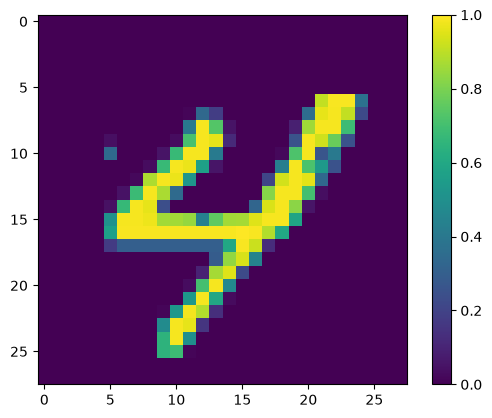

In [19]:
index = 89
print(y_train[index])
plt.figure()
plt.imshow(x_train[index])
plt.colorbar()
plt.grid(False)
plt.show()

#### Build a machine learning model

Sequential model is useful for stacking layers where each layer has one input tensor and one output tensor. Layers are functions with a known mathematical structure that can be reused and have trainable variables. Most TensorFlow models are composed of layers. This model uses the Flatten, Dense, and Dropout layers.

In [20]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10)
])

/home/zoe/Github/deep_learning_course/.venv-1/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


For each example, the model returns a vector of logits or log-odds scores, one for each class.

In [21]:
predictions = model(x_train[:1]).numpy()
predictions

array([[-0.17488585, -0.2782719 , -0.18383777,  0.1612094 , -0.53551865,
         0.14915815, -0.5826112 , -0.23287751,  0.6459934 ,  0.14896324]],
      dtype=float32)

The `tf.nn.softmax`function converts these logits to probabilities for each class:

In [22]:
tf.nn.softmax(predictions).numpy()

array([[0.08593991, 0.07749878, 0.08517401, 0.12027052, 0.0599203 ,
        0.11882981, 0.05716392, 0.08109786, 0.1952982 , 0.11880666]],
      dtype=float32)

Define a loss function for training using `losses.SparseCategoricalCrossentropy`:

In [23]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

The loss function takes a vector of ground truth values and a vector of logits and returns a scalar loss for each example. This loss is equal to the negative log probability of the true class: The loss is zero if the model is sure of the correct class.

This untrained model gives probabilities close to random (1/10 for each class), so the initial loss should be close to `-tf.math.log(1/10) ~= 2.3`.

In [24]:
loss_fn(y_train[:1], predictions).numpy()

np.float32(2.1300628)

Before you start training, configure and compile the model using Keras `Model.compile`. Set the optimizer class to `adam`, set the `loss` to the `loss_fn` function you defined earlier, and specify a `metric` to be evaluated for the `model` by setting the `etrics` parameter to `accuracy`.

In [25]:
model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

#### Train and evaluate your model
Use the `Model.fit` method to adjust your `model` parameters and minimize the `loss`:

In [26]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5


I0000 00:00:1789218595.547749    9369 service.cc:153] XLA service 0x5ae44b4a4e30 initialized for platform ROCM (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789218595.547764    9369 service.cc:161]   StreamExecutor [0]: AMD Radeon RX 6800 XT, AMDGPU ISA version: gfx1030 (Driver: 7.14.60850; Runtime: 7.14.60850; Toolkit: 7.14.60850; DNN: 0.0.0)
I0000 00:00:1789218595.573672    9369 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1789218595.708242    9369 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1008__XlaMustCompile_true_config_proto_2201667018877855759_executor_type_11160318154034397263_.11


   1/1875 ━━━━━━━━━━━━━━━━━━━━ 1:06:49 2s/step - accuracy: 0.0625 - loss: 2.4017

I0000 00:00:1789218597.224078    9369 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9118 - loss: 0.3025
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9577 - loss: 0.1439
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9674 - loss: 0.1073
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9742 - loss: 0.0854
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9772 - loss: 0.0730


The `Model.evaluate` method checks the model's performance, usually on a validation set or test set.

In [27]:
model.evaluate(x_test,  y_test, verbose=2)

313/313 - 1s - 4ms/step - accuracy: 0.9775 - loss: 0.0743


[0.07430034130811691, 0.9775000214576721]

The image classifier is now trained to ~98% accuracy on this dataset. 

### Predictions on the 4 random test samples

The model outputs logits, so I wrapped it in a `Softmax` layer to get probabilities. I then drew 4 random indices from the 10,000-image test set (with a fixed seed so the same 4 images are used again for the reduced-training-set comparison in Part C), plotted them, and printed the predicted digit next to the true label.

In [28]:
import numpy as np

# Draw 4 random samples from the test set. 
rng = np.random.default_rng(seed=89)
sample_idx = rng.choice(len(x_test), size=4, replace=False)
print("Test indices:", sample_idx)

Test indices: [5756 7699 2512 8581]


In [29]:
def predict_samples(trained_model, indices):
    # Returns predicted labels and confidences for the given test-set indices. Softmax is used to convert to probabilities.

    probability_model = tf.keras.Sequential([trained_model, tf.keras.layers.Softmax()])
    probabilities = probability_model(x_test[indices]).numpy()
    return np.argmax(probabilities, axis=1), probabilities.max(axis=1)


full_preds, full_conf = predict_samples(model, sample_idx)

for i, idx in enumerate(sample_idx):
    print(f"test[{idx}]: predicted {full_preds[i]}, actual {y_test[idx]}, "
          f"confidence {full_conf[i]:.4f}")

test[5756]: predicted 0, actual 0, confidence 1.0000
test[7699]: predicted 0, actual 0, confidence 1.0000
test[2512]: predicted 8, actual 8, confidence 0.9962
test[8581]: predicted 3, actual 3, confidence 0.9990


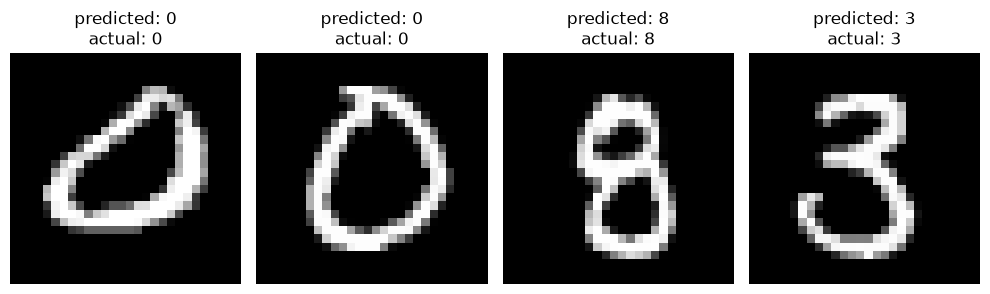

In [30]:
# Display the 4 chosen images with the model's prediction and the true label
plt.figure(figsize=(10, 3))
for i, idx in enumerate(sample_idx):
    plt.subplot(1, 4, i + 1)
    plt.imshow(x_test[idx], cmap="gray")
    plt.grid(False)
    plt.axis("off")
    plt.title(f"predicted: {full_preds[i]}\nactual: {y_test[idx]}")
plt.tight_layout()
plt.show()

**Results for the 4 random samples (model trained on all 60,000 images):**

The selected test indices are 5756, 7699, 2512, and 8581. The model classified all four correctly:

| Test index | Predicted digit | Actual digit | Confidence |
|---|---|---|---|
| 5756 | 0 | 0 | 1.0000 |
| 7699 | 0 | 0 | 1.0000 |
| 2512 | 8 | 8 | 0.9962 |
| 8581 | 3 | 3 | 0.9990 |

All four predictions are made with almost 100% confidence. The lowest confidence is the 8 at index 2512 (at 0.9962), which is possibly because 8 is one of the more easily confused digits in MNIST.

### Repeating the experiment with 10,000 training samples

Here I rebuild the identical architecture and train it for the same 5 epochs, but on only the first 10,000 images of the training set instead of all 60,000. Everything else is the same, so the trainiing set size change is responsible for any difference in accuracy.

In [31]:
# Reduce the training set to the first 10,000 samples
x_train_small, y_train_small = x_train[:10000], y_train[:10000]
print(x_train_small.shape, y_train_small.shape)

(10000, 28, 28) (10000,)


In [32]:
# Same architecture as above
model_small = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10)
])

model_small.compile(optimizer='adam',
                    loss=loss_fn,
                    metrics=['accuracy'])

In [33]:
model_small.fit(x_train_small, y_train_small, epochs=5)

Epoch 1/5


I0000 00:00:1789218632.150671    9369 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_60330__XlaMustCompile_true_config_proto_2201667018877855759_executor_type_11160318154034397263_.11


305/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8402 - loss: 0.5635

I0000 00:00:1789218633.279825    9369 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_62535__XlaMustCompile_true_config_proto_2201667018877855759_executor_type_11160318154034397263_.11


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8423 - loss: 0.5562
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9197 - loss: 0.2745
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9398 - loss: 0.2068
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9537 - loss: 0.1623
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9593 - loss: 0.1381


In [34]:
# Evaluate on the full test set (as above)
small_loss, small_accuracy = model_small.evaluate(x_test, y_test, verbose=2)
print(f"Reduced-training-set model -> loss: {small_loss:.4f}, accuracy: {small_accuracy:.4f}")

313/313 - 1s - 3ms/step - accuracy: 0.9451 - loss: 0.1789
Reduced-training-set model -> loss: 0.1789, accuracy: 0.9451


In [ ]:
# Predictions from the reduced model on the same 4 test samples
small_preds, small_conf = predict_samples(model_small, sample_idx)

print(f"{'index':>7} {'actual':>7} {'full':>6} {'conf':>8} {'10k':>6} {'conf':>8}")
for i, idx in enumerate(sample_idx):
    print(f"{idx:>7} {y_test[idx]:>7} {full_preds[i]:>6} {full_conf[i]:>8.4f} "
 f"{small_preds[i]:>6} {small_conf[i]:>8.4f}")

  index  actual   full     conf    10k     conf
   5756       0      0   1.0000      0   0.9954
   7699       0      0   1.0000      0   0.9999
   2512       8      8   0.9962      8   0.8700
   8581       3      3   0.9990      3   0.9449


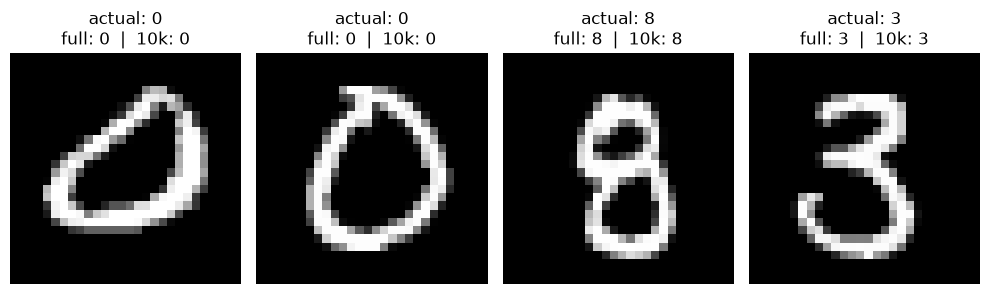

In [36]:
# Comparing the same 4 images under both models
plt.figure(figsize=(10, 3))
for i, idx in enumerate(sample_idx):
    plt.subplot(1, 4, i + 1)
    plt.imshow(x_test[idx], cmap="gray")
    plt.grid(False)
    plt.axis("off")
    plt.title(f"actual: {y_test[idx]}\nfull: {full_preds[i]}  |  10k: {small_preds[i]}")
plt.tight_layout()
plt.show()

**Comparison of the two runs:**

| | Training samples | Steps per epoch | Final training accuracy | Test accuracy | Test loss |
|---|---|---|---|---|---|
| Original model | 60,000 | 1875 | 0.9772 | 0.9775 | 0.0743 |
| Reduced model | 10,000 | 313 | 0.9593 | 0.9451 | 0.1789 |

**Predictions on the same 4 samples:**

| Test index | Actual | 60,000-sample model | Confidence | 10,000-sample model | Confidence |
|---|---|---|---|---|---|
| 5756 | 0 | 0 | 1.0000 | 0 | 0.9954 |
| 7699 | 0 | 0 | 1.0000 | 0 | 0.9999 |
| 2512 | 8 | 8 | 0.9962 | 8 | 0.8700 |
| 8581 | 3 | 3 | 0.9990 | 3 | 0.9449 |

**Observations:**

Reducing the training set from 60,000 samples to 10,000 resulted in a loss of 3.2 percentage points of test accuracy (from 0.9775 down to 0.9451). The error rate rose from 2.25% to 5.49%, so the smaller model makes roughly 2.4 times as many mistakes on the same 10,000 image test set.

Both models still classify all four sampled digits correctly, but the reduced model is less confident, most noticeably on the 8 at index 2512, which drops from 0.9962 to 0.8700.

### Running the notebook in Google Colab

I ran the same notebook end to end in Google Colab. The environment differs from my local machine in both TensorFlow version and hardware: Colab used TensorFlow 2.20.0 on Python 3.13, while my local environment uses TensorFlow 2.21.0-dev0 with ROCm on an AMD Radeon RX 6800 XT. Colab also had to download MNIST at the start of the session, which my local run did not, since the dataset was already cached.

Training output from the Colab run:

```
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9140 - loss: 0.2982
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9573 - loss: 0.1439
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9670 - loss: 0.1079
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9730 - loss: 0.0881
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9762 - loss: 0.0742
```

Evaluation on the test set:

```
313/313 - 2s - 6ms/step - accuracy: 0.9787 - loss: 0.0695
```

**Comparison of the local and Colab runs of the lecture notebook:**

| | TensorFlow | Test accuracy | Test loss | Initial loss on untrained model |
|---|---|---|---|---|
| Local (ROCm, RX 6800 XT) | 2.21.0-dev0 | 0.9775 | 0.0743 | 2.1301 |
| Google Colab | 2.20.0 | 0.9787 | 0.0695 | 2.3523 |

The two runs produce similar results. Test accuracy differs by 0.12 percentage points, and this level of variation is expected also because the model weights are randomly initialized and the dropout mask is random. The initial loss values on the untrained model are 2.1301 locally and 2.3532, both seemingly scattered around the `-log(1/10) ≈ 2.3` value the notebook predicts for a randomly initialized 10-class model. Per-epoch training accuracies are also similar, reaching about 0.91 after the first epoch in both environments.
```